# Restoration of original segmentation: legacy vs. fixed (untokenized vs. SPM)

This notebook compares how well `mweralign` restores the *original* per-segment
segmentation of WMT24 system outputs under several conditions:

| variant       | build   | segmenter            | description                                  |
|---------------|---------|----------------------|----------------------------------------------|
| `legacy_none` | pre-fix | none (whitespace)    | unconditional penalty (paper behavior)       |
| `none`        | fixed   | none (whitespace)    | penalty gated on tokenization (the fix)      |
| `spm32k`      | fixed   | identity SPM, 32k    | tokenized alignment                          |
| `spm64k`      | fixed   | identity SPM, 64k    | tokenized alignment                          |
| `spm128k`     | fixed   | identity SPM, 128k   | tokenized alignment                          |
| `spm256k`     | fixed   | identity SPM, 256k   | tokenized alignment                          |

Two metrics, aggregated over systems that succeeded under **all** variants
(so the comparison is apples-to-apples):

- **boundary_acc** — % of interior segment boundaries placed exactly on the gold boundary
- **seg_exact** — % of segments restored verbatim

The per-system TSVs are produced by `restoration_rate.py`:

```bash
python -m scripts.experiments.restoration_rate --segmenter none --legacy-penalty \
    --label legacy --per-system-tsv results/restore_legacy.tsv
python -m scripts.experiments.restoration_rate --segmenter none \
    --label fixed  --per-system-tsv results/restore_fixed.tsv
for v in 32k 64k 128k 256k; do
  python -m scripts.experiments.restoration_rate --segmenter spm$v \
      --label spm$v --per-system-tsv results/restore_spm$v.tsv
done
```


In [41]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Results live under <repo>/expt/results. Resolve relative to this notebook so
# it works regardless of the kernel's working directory.
def _find_results():
    here = Path.cwd()
    for base in (here, *here.parents):
        cand = base / "expt" / "results"
        if cand.exists():
            return cand
    return Path("expt/results")

RESULTS = _find_results()

# variant key -> (tsv filename, human label)
VARIANTS = {
    "legacy_none": ("restore_legacy.tsv",  "legacy (none)"),
    "none":        ("restore_fixed.tsv",   "fixed (none)"),
    "spm32k":      ("restore_spm32k.tsv",  "spm 32k"),
    "spm64k":      ("restore_spm64k.tsv",  "spm 64k"),
    "spm128k":     ("restore_spm128k.tsv", "spm 128k"),
    "spm256k":     ("restore_spm256k.tsv", "spm 256k"),
}


In [42]:
def load(path):
    """Load a per-system restoration TSV, keeping only successful systems."""
    df = pd.read_csv(path, sep="\t")
    df = df[df["ok"] == 1].copy()
    for col in ["n_boundaries", "boundaries_correct", "n_segments", "segments_exact"]:
        df[col] = df[col].astype(int)
    return df.set_index(["langpair", "system"])


frames = {key: load(RESULTS / fname) for key, (fname, _) in VARIANTS.items()}
for key, df in frames.items():
    print(f"{key:12s} systems ok: {len(df)}")

legacy_none  systems ok: 242
none         systems ok: 242
spm32k       systems ok: 242
spm64k       systems ok: 242
spm128k      systems ok: 242
spm256k      systems ok: 242


In [43]:
# Intersect on (langpair, system) pairs that succeeded under ALL variants.
common = set.intersection(*(set(df.index) for df in frames.values()))
common = sorted(common)
print(f"systems common to all variants: {len(common)}")

frames = {key: df.loc[df.index.isin(common)] for key, df in frames.items()}

systems common to all variants: 242


In [44]:
def aggregate(df):
    """Per-langpair boundary_acc and seg_exact (micro-averaged over systems)."""
    g = df.groupby(level="langpair").sum(numeric_only=True)
    out = pd.DataFrame(index=g.index)
    out["n_sys"] = df.groupby(level="langpair").size()
    out["boundary_acc"] = 100.0 * g["boundaries_correct"] / g["n_boundaries"]
    out["seg_exact"] = 100.0 * g["segments_exact"] / g["n_segments"]
    return out


per_lp = {key: aggregate(df) for key, df in frames.items()}

# Wide table: one row per langpair, boundary_acc + seg_exact per variant.
langpairs = sorted(per_lp["none"].index)
wide = pd.DataFrame(index=langpairs)
wide.index.name = "langpair"
wide["n_sys"] = per_lp["none"].loc[langpairs, "n_sys"]
for key, (_, label) in VARIANTS.items():
    wide[f"boundary_acc[{key}]"] = per_lp[key].loc[langpairs, "boundary_acc"]
for key, (_, label) in VARIANTS.items():
    wide[f"seg_exact[{key}]"] = per_lp[key].loc[langpairs, "seg_exact"]

# Add an ALL (micro-average over every system in every langpair) row.
all_row = {"n_sys": int(sum(len(df) for df in frames.values()) / len(frames))}
for key, df in frames.items():
    s = df.sum(numeric_only=True)
    all_row[f"boundary_acc[{key}]"] = 100.0 * s["boundaries_correct"] / s["n_boundaries"]
    all_row[f"seg_exact[{key}]"] = 100.0 * s["segments_exact"] / s["n_segments"]
wide.loc["ALL"] = all_row

wide.round(2)

,n_sys,boundary_acc[legacy_none],boundary_acc[none],boundary_acc[spm32k],boundary_acc[spm64k],boundary_acc[spm128k],boundary_acc[spm256k],seg_exact[legacy_none],seg_exact[none],seg_exact[spm32k],seg_exact[spm64k],seg_exact[spm128k],seg_exact[spm256k]
langpair,,,,,,,,,,,,,
cs-uk,20,0.56,79.84,84.89,85.29,85.95,85.76,0.24,67.03,76.08,76.69,77.48,77.20
en-cs,26,5.94,70.77,79.92,80.00,81.04,81.88,2.08,54.14,67.52,67.54,68.95,70.31
en-de,26,5.04,72.08,83.56,83.43,85.09,84.27,1.86,54.46,71.16,71.17,73.73,72.80
en-es,23,2.35,80.99,88.46,87.80,88.41,88.39,0.62,68.17,80.46,79.51,80.43,80.38
en-hi,18,7.12,67.10,77.22,78.10,78.99,79.10,5.87,49.53,63.43,64.57,66.32,66.05
en-is,19,10.57,64.22,77.95,78.97,79.62,79.91,6.78,44.82,63.87,65.22,66.53,67.07
en-ja,23,6.19,68.37,95.18,95.07,94.82,93.47,1.24,21.92,91.27,91.10,90.70,88.27
en-ru,24,1.32,61.27,77.19,78.87,78.71,79.09,0.33,42.15,64.01,66.65,66.27,66.76
en-uk,20,1.07,74.19,85.95,85.76,86.17,86.56,0.22,58.65,76.01,75.72,76.08,76.71


## Combined TSVs

A **wide** TSV (one row per langpair, easy to read) and a **tidy/long** TSV
(`langpair, variant, metric, value` — easy to plot with any tool) are written to
`results/`.

In [45]:
wide.round(4).to_csv(RESULTS / "restoration_comparison_wide.tsv", sep="\t")

# Tidy/long form for plotting tools.
records = []
for key, (_, label) in VARIANTS.items():
    for lp in langpairs:
        for metric in ("boundary_acc", "seg_exact"):
            records.append({
                "langpair": lp,
                "variant": key,
                "variant_label": label,
                "metric": metric,
                "value": float(per_lp[key].loc[lp, metric]),
            })
tidy = pd.DataFrame.from_records(records)
tidy.to_csv(RESULTS / "restoration_comparison_tidy.tsv", sep="\t", index=False)
print("wrote results/restoration_comparison_wide.tsv")
print("wrote results/restoration_comparison_tidy.tsv")
tidy.head()

wrote results/restoration_comparison_wide.tsv
wrote results/restoration_comparison_tidy.tsv


,langpair,variant,variant_label,metric,value
0,cs-uk,legacy_none,legacy (none),boundary_acc,0.556036
1,cs-uk,legacy_none,legacy (none),seg_exact,0.243955
2,en-cs,legacy_none,legacy (none),boundary_acc,5.937718
3,en-cs,legacy_none,legacy (none),seg_exact,2.079315
4,en-de,legacy_none,legacy (none),boundary_acc,5.039120


wrote results/restoration_comparison.png


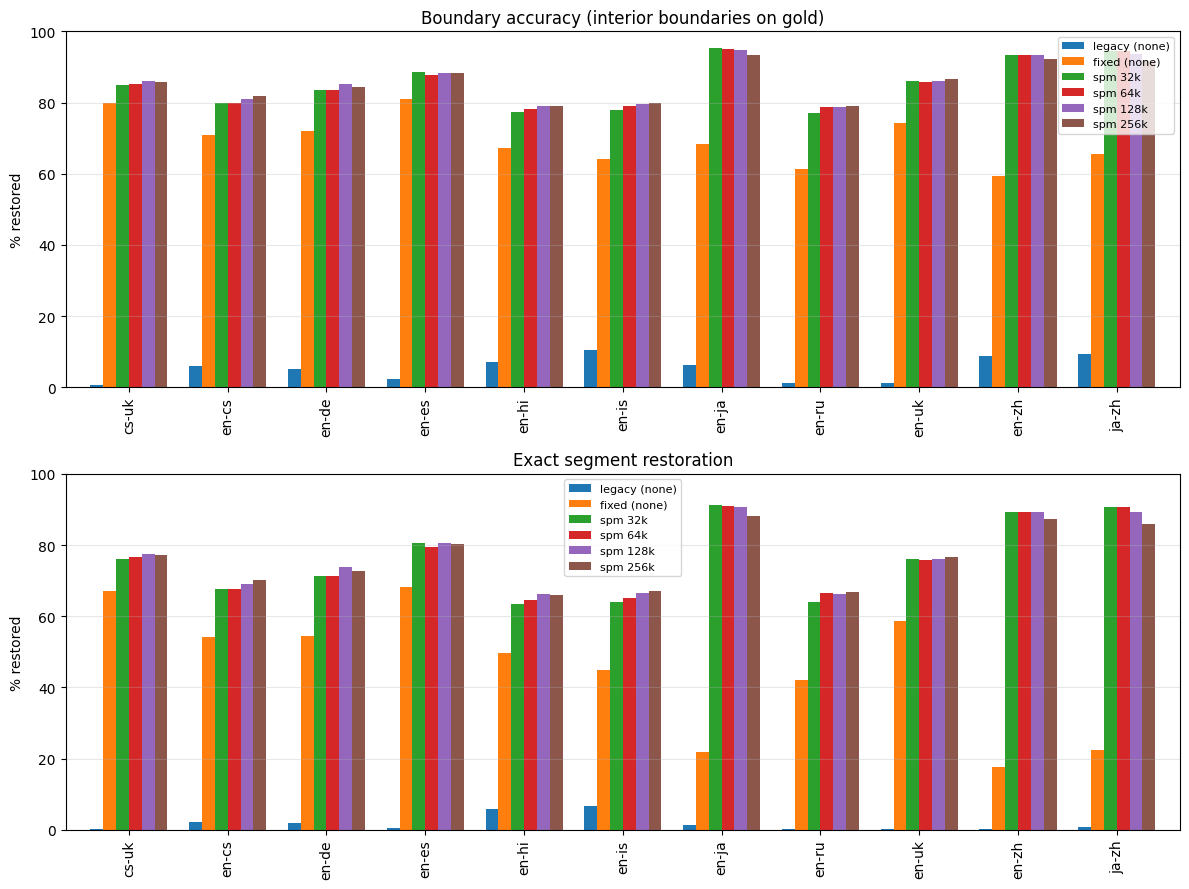

In [46]:
def grouped_bar(metric, title, ax):
    pivot = tidy[tidy["metric"] == metric].pivot(
        index="langpair", columns="variant", values="value")
    pivot = pivot.loc[langpairs, list(VARIANTS)]  # consistent order
    pivot.columns = [VARIANTS[c][1] for c in pivot.columns]
    pivot.plot(kind="bar", ax=ax, width=0.78)
    ax.set_title(title)
    ax.set_ylabel("% restored")
    ax.set_xlabel("")
    ax.set_ylim(0, 100)
    ax.legend(title="", fontsize=8)
    ax.grid(axis="y", alpha=0.3)


fig, axes = plt.subplots(2, 1, figsize=(12, 9))
grouped_bar("boundary_acc", "Boundary accuracy (interior boundaries on gold)", axes[0])
grouped_bar("seg_exact", "Exact segment restoration", axes[1])
fig.tight_layout()
fig.savefig(RESULTS / "restoration_comparison.png", dpi=150, bbox_inches="tight")
print("wrote results/restoration_comparison.png")
plt.show()

## Cost profile: wall time vs. problem size

`restoration_rate.py` also records, for **every** (system, segmenter) pair, the
size drivers and the measured subprocess wall time:

- `n_segments`, `total_words`, `avg_words_per_seg` — system output size
- `n_domains` — number of domain-merged groups (the DP is run per group)
- `max_domain_words` — largest merged group (whitespace words); the main driver
- `sum_domain_sq` — Σ over domains of `merged_words²`, a proxy for the O(J·S) DP work
- `wall_seconds` — wall-clock time for the full realignment subprocess

The merged group (not the individual ~21-word segment) is what makes a single
realignment take seconds: each domain's segments are concatenated into one
stream of thousands of tokens before the dynamic program runs.

In [47]:
# Combine the per-system profiling rows from all three runs into one TSV,
# tagging each with its variant label.
prof_parts = []
for key, (fname, label) in VARIANTS.items():
    p = pd.read_csv(RESULTS / fname, sep="\t")
    p["variant"] = key
    p["variant_label"] = label
    prof_parts.append(p)
prof = pd.concat(prof_parts, ignore_index=True)

prof_cols = ["variant", "variant_label", "langpair", "system", "segmenter", "ok",
             "n_segments", "total_words", "avg_words_per_seg", "n_domains",
             "max_domain_words", "sum_domain_sq", "wall_seconds"]
prof = prof[prof_cols]
prof.to_csv(RESULTS / "realign_profile.tsv", sep="\t", index=False)
print(f"wrote results/realign_profile.tsv  ({len(prof)} rows)")

prof.groupby("variant_label")[["avg_words_per_seg", "max_domain_words",
                               "sum_domain_sq", "wall_seconds"]].mean().round(2)

wrote results/realign_profile.tsv  (1452 rows)


,avg_words_per_seg,max_domain_words,sum_domain_sq,wall_seconds
variant_label,,,,
fixed (none),21.31,6196.48,169053444.6,1.54
legacy (none),21.31,6196.48,169053444.6,1.60
spm 128k,21.31,6196.48,169053444.6,6.84
spm 256k,21.31,6196.48,169053444.6,5.73
spm 32k,21.31,6196.48,169053444.6,22.07
spm 64k,21.31,6196.48,169053444.6,8.81


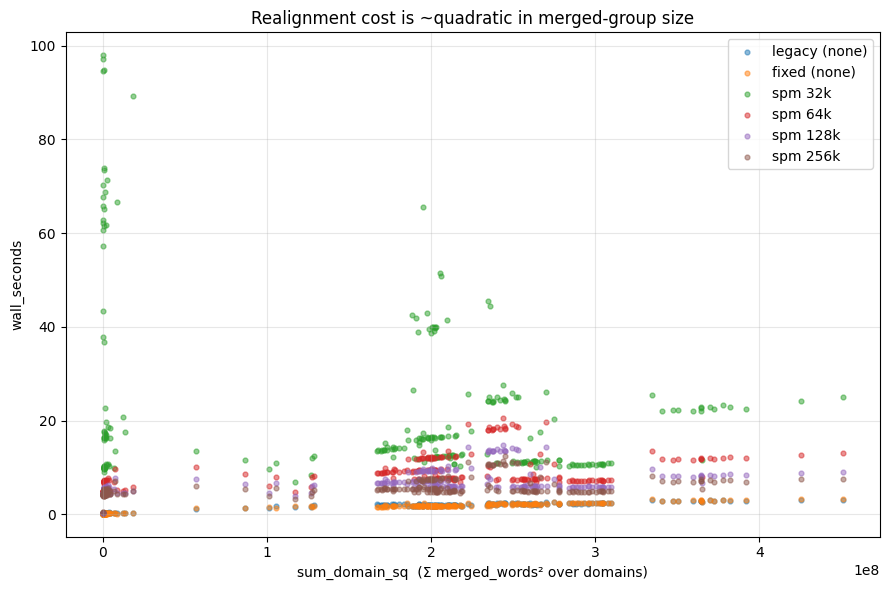

In [48]:
# Wall time scales with sum_domain_sq (the O(J·S) DP work proxy).
fig, ax = plt.subplots(figsize=(9, 6))
for key, (_, label) in VARIANTS.items():
    sub = prof[prof["variant"] == key]
    ax.scatter(sub["sum_domain_sq"], sub["wall_seconds"], s=12, alpha=0.5, label=label)
ax.set_xlabel("sum_domain_sq  (Σ merged_words² over domains)")
ax.set_ylabel("wall_seconds")
ax.set_title("Realignment cost is ~quadratic in merged-group size")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS / "realign_cost_scatter.png", dpi=150, bbox_inches="tight")
plt.show()